In [3]:
import torch
import torchvision
import torchvision.transforms as T
import os
import numpy as np
import cv2
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_Weights

In [4]:
os.getcwd()

'/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/baselineModels/maskrcnn'

In [5]:
os.chdir("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images")
print(os.getcwd())
from get_bounding_box_cordinates import bounding_box

/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images


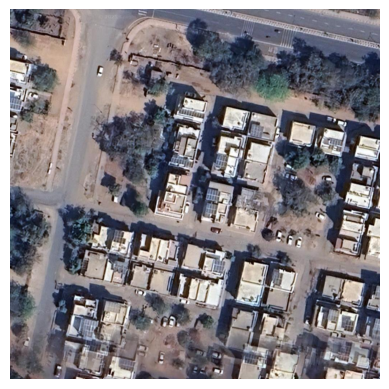

In [6]:
demo_img = cv2.imread("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/gandhinagar_dataset/train/images/sample_0_jpg.rf.1effac9516766533e424f9df1a80484c.jpg")
demo_img = cv2.cvtColor(demo_img, cv2.COLOR_BGR2RGB)
import matplotlib.pyplot as plt
plt.imshow(demo_img)
plt.axis('off')
plt.show()

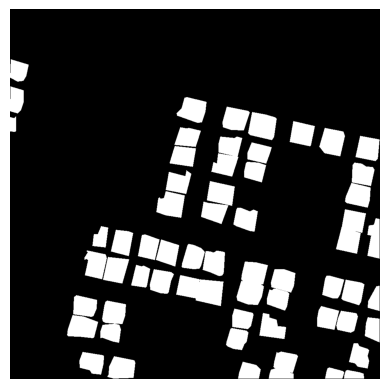

In [7]:
demo_mask = cv2.imread("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/gandhinagar_dataset/train/masks/sample_0_jpg.rf.1effac9516766533e424f9df1a80484c_mask.png",cv2.IMREAD_GRAYSCALE)
plt.imshow(demo_mask, cmap='gray')
plt.axis('off')
plt.show()

In [8]:
import cv2
import numpy as np

def extract_individual_objects(input_mask):
    # Ensure the input is a binary mask (0 and 255 values)
    _, binary_mask = cv2.threshold(input_mask, 127, 255, cv2.THRESH_BINARY)

    # Find contours (connected components) in the binary mask
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # List to hold individual object masks
    object_masks = []
    bounding_boxes = []

    # Iterate over each contour to create an individual mask
    for contour in contours:
        # Create a blank mask with the same size as the original mask
        object_mask = np.zeros_like(binary_mask)
        
        x, y, w, h = cv2.boundingRect(contour)
        bounding_boxes.append((x, y, x+w, y+h))
        
        # Draw the current contour on the object mask (white)
        cv2.drawContours(object_mask, [contour], -1, (255), thickness=cv2.FILLED)

        # Append the object mask to the list
        object_masks.append(object_mask)

    return object_masks, bounding_boxes

In [9]:
demo_mask.shape

(1024, 1024)

In [10]:
multiple_masks, bb = extract_individual_objects(demo_mask)
len(multiple_masks), len(bb)

(54, 54)

In [11]:
M = np.array(multiple_masks)
M

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [12]:
M.shape

(54, 1024, 1024)

In [13]:
multiple_masks[0].shape

(1024, 1024)

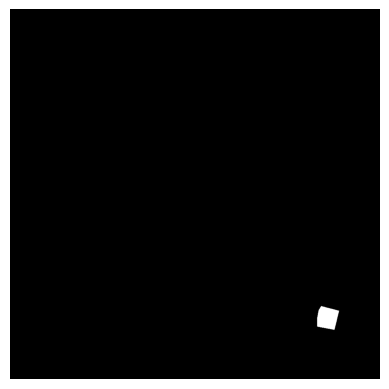

In [15]:
plt.imshow(multiple_masks[13], cmap='gray')
plt.axis('off')
plt.show()

# Final Code 

In [1]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

In [3]:
print(os.getcwd())
os.chdir("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images")
print(os.getcwd())

/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/baselineModels/maskrcnn
/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images


In [4]:
# Your function to extract individual masks and bounding boxes
def extract_individual_objects(input_mask):
    # Ensure the input is a binary mask (0 and 255 values)
    _, binary_mask = cv2.threshold(input_mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    object_masks = []
    bounding_boxes = []
    for contour in contours:
        object_mask = np.zeros_like(binary_mask)
        x, y, w, h = cv2.boundingRect(contour)
        bounding_boxes.append([x, y, x + w, y + h])  # [x_min, y_min, x_max, y_max]
        cv2.drawContours(object_mask, [contour], -1, 255, thickness=cv2.FILLED)
        object_masks.append(object_mask // 255)  # Convert to 0/1 binary
    return object_masks, bounding_boxes

In [5]:
# Define the dataset
class RooftopDataset(Dataset):
    def __init__(self, root, transforms=None):
        self.root = root
        self.transforms = transforms
        self.images_dir = os.path.join(root, 'images')
        self.masks_dir = os.path.join(root, 'masks')
        self.imgs = sorted([f for f in os.listdir(self.images_dir) if f.endswith(('.jpg', '.png'))])
        self.masks = sorted([f for f in os.listdir(self.masks_dir) if f.endswith(('.jpg', '.png'))])
        assert len(self.imgs) == len(self.masks), "Mismatch between images and masks"

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.imgs[idx])
        mask_path = os.path.join(self.masks_dir, self.masks[idx])

        # Load image
        img = cv2.imread(img_path)
        if img is None:
            raise FileNotFoundError(f"Failed to load image: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = T.ToTensor()(img)  # Shape: (3, 1024, 1024)

        # Load multi-instance mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            # print(f"Warning: Mask failed to load for {mask_path}")
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            masks = torch.zeros((0, 1024, 1024), dtype=torch.uint8)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            # Extract individual masks and boxes
            instance_masks, boxes = extract_individual_objects(mask)
            if not instance_masks or not boxes:
                # print(f"No rooftops detected in {img_path}")
                boxes = torch.zeros((0, 4), dtype=torch.float32)
                masks = torch.zeros((0, 1024, 1024), dtype=torch.uint8)
                labels = torch.zeros((0,), dtype=torch.int64)
            else:
                # Validate consistency
                assert len(boxes) == len(instance_masks), f"Mismatch: {len(boxes)} boxes vs {len(instance_masks)} masks"
                
                # Stack masks and convert to tensor
                masks = np.stack(instance_masks, axis=0)  # Shape: (num_instances, 1024, 1024)
                masks = torch.from_numpy(masks).to(dtype=torch.uint8)
                
                # Convert boxes to tensor
                boxes = torch.as_tensor(boxes, dtype=torch.float32)  # Shape: (num_instances, 4)
                
                # Assign labels (all 1 for rooftops)
                labels = torch.ones((len(instance_masks),), dtype=torch.int64)
                
                # Debug info
                # print(f"{img_path}: {len(instance_masks)} rooftops")

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": torch.tensor([idx])
        }

        if self.transforms:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.imgs)

In [6]:
# Load and modify the model
def get_model_instance_segmentation(num_classes=2):  # Background (0) + Rooftop (1)
    model = maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)
    return model

In [7]:
# Training function with enhanced logging
def train_model(model, data_loader, optimizer, device, num_epochs=10):
    # print("Training the model...")
    model.to(device)
    model.train()
    losses_list = []

    for epoch in range(num_epochs):
        # print(f"Epoch {epoch+1}/{num_epochs}")
        total_loss = 0
        for i, (images, targets) in enumerate(data_loader):
            # print(f"Batch {i+1}: Images and targets loaded")
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            
            # Log individual losses
            # print(f"Batch {i+1} losses: { {k: v.item() for k, v in loss_dict.items()} }")
            
            optimizer.zero_grad()
            losses.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Stabilize training
            optimizer.step()

            total_loss += losses.item()
        
        total_loss = total_loss / len(data_loader)
        print(total_loss)
        losses_list.append(total_loss)
        
        print(f"Epoch [{epoch+1}/{num_epochs}], Total Loss: {total_loss:.4f}")

    return losses_list

In [13]:
root_dir = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/gandhinagar_dataset/train"
dataset = RooftopDataset(root_dir)
data_loader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=2, collate_fn=lambda x: tuple(zip(*x)))

print("Data is loaded")

device = torch.device("cuda")
num_epochs = 50
num_classes = 2
learning_rate = 0.0001

print("parameter are set")

# model = get_model_instance_segmentation(num_classes=num_classes)
# model.to(device)

model_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/BaseLineModels/Maksed_RCNN/mask_rcnn_epoch_50_full.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the fine-tuned model
def load_finetuned_model(model_path):
    my_model = torch.load(model_path, weights_only=False)
    my_model.to(device)
    my_model.eval()
    return my_model


# Load model and test data
model = load_finetuned_model(model_path)


optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

loss = train_model(model, data_loader, optimizer, device, num_epochs=num_epochs)

save_dir = '/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/baselineModels/maskrcnn'

os.makedirs(save_dir, exist_ok=True)
# save_path = os.path.join(save_dir, f'mask_rcnn_epoch_{num_epochs}_scratch.pth')
save_path = os.path.join(save_dir, f'mask_rcnn_epoch_{num_epochs}_usa.pth')

torch.save({'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict()}, save_path)


save_path = os.path.join(save_dir, f'mask_rcnn_epoch_{num_epochs}_full_usa.pth')
torch.save(model, save_path)

print(f"Model saved at {save_path}")

Data is loaded
parameter are set
1.0981367212622912
Epoch [1/50], Total Loss: 1.0981
0.8549007484272345
Epoch [2/50], Total Loss: 0.8549
0.7800756421551776
Epoch [3/50], Total Loss: 0.7801
0.7220855141753582
Epoch [4/50], Total Loss: 0.7221
0.6671444969390755
Epoch [5/50], Total Loss: 0.6671
0.6056876129178859
Epoch [6/50], Total Loss: 0.6057
0.5437975245625225
Epoch [7/50], Total Loss: 0.5438
0.5004087537527084
Epoch [8/50], Total Loss: 0.5004
0.4603176568426303
Epoch [9/50], Total Loss: 0.4603
0.4303033138389018
Epoch [10/50], Total Loss: 0.4303
0.3995881687794159
Epoch [11/50], Total Loss: 0.3996
0.38270074573915397
Epoch [12/50], Total Loss: 0.3827
0.3615324664026944
Epoch [13/50], Total Loss: 0.3615
0.3464637876891378
Epoch [14/50], Total Loss: 0.3465
0.32493374630141614
Epoch [15/50], Total Loss: 0.3249
0.31351242114358874
Epoch [16/50], Total Loss: 0.3135
0.30028117759459055
Epoch [17/50], Total Loss: 0.3003
0.2889549767793114
Epoch [18/50], Total Loss: 0.2890
0.276283595099378


In [14]:
loss

[1.0981367212622912,
 0.8549007484272345,
 0.7800756421551776,
 0.7220855141753582,
 0.6671444969390755,
 0.6056876129178859,
 0.5437975245625225,
 0.5004087537527084,
 0.4603176568426303,
 0.4303033138389018,
 0.3995881687794159,
 0.38270074573915397,
 0.3615324664026944,
 0.3464637876891378,
 0.32493374630141614,
 0.31351242114358874,
 0.30028117759459055,
 0.2889549767793114,
 0.276283595099378,
 0.26320805823180216,
 0.2568424009342692,
 0.2553893268775584,
 0.24752259109892064,
 0.24198503147310285,
 0.23833222753966032,
 0.23115828811232722,
 0.22334274238170082,
 0.21870865305857873,
 0.21450342338031797,
 0.21408357159860097,
 0.2090282778241741,
 0.20546146015177913,
 0.20360155514816738,
 0.20153928381293568,
 0.2002528175266821,
 0.1949119294312463,
 0.18931235217336398,
 0.18737650573698442,
 0.1864761006253869,
 0.18423702178606347,
 0.176748858903771,
 0.17716099077196262,
 0.17552856544950116,
 0.1754829819077876,
 0.17466237484963973,
 0.17461244684101931,
 0.1755877923

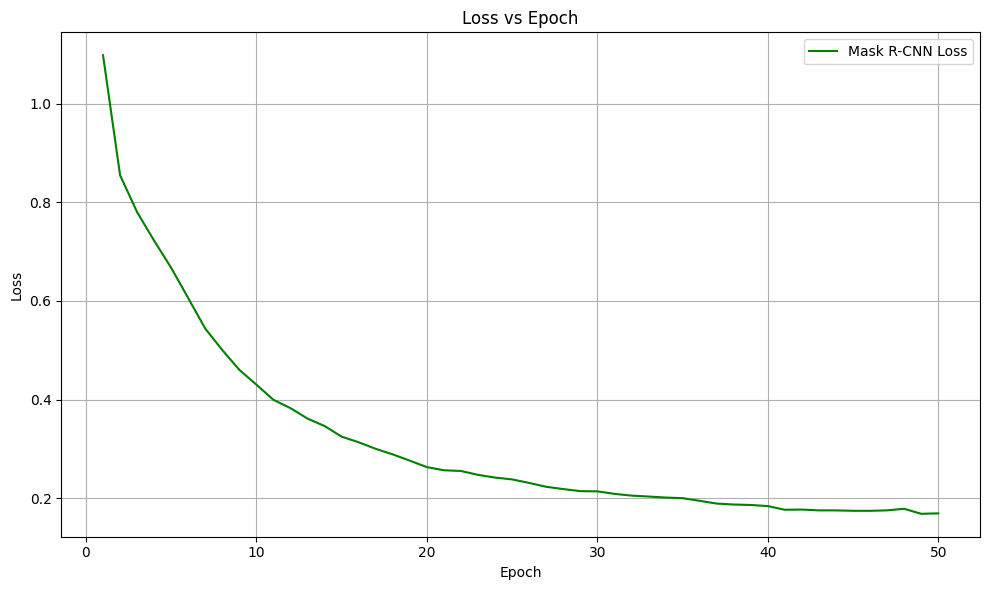

In [15]:
import matplotlib.pyplot as plt
epochs = list(range(1, 51))  
maskrcnn_loss = loss
# Plot Loss
plt.figure(figsize=(10, 6))
plt.plot(epochs, maskrcnn_loss, label='Mask R-CNN Loss', color='green')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.grid(True)
plt.savefig("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/baselineModels/maskrcnn/Epoch_vs_Loss_maskRCNN_usa.png")
plt.tight_layout()
plt.show()


# Test Model 

In [26]:
# Load the fine-tuned model
def load_finetuned_model(model_path):
    my_model = torch.load(model_path, weights_only=False)
    my_model.to(device)
    my_model.eval()
    return my_model

In [27]:
from accuracy_indian import compute_metrics

In [28]:
def calculate_iou(box1, box2):
    x1, y1, x2, y2 = box1
    x1_p, y1_p, x2_p, y2_p = box2

    xi1, yi1 = max(x1, x1_p), max(y1, y1_p)
    xi2, yi2 = min(x2, x2_p), min(y2, y2_p)
    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)

    box1_area = (x2 - x1) * (y2 - y1)
    box2_area = (x2_p - x1_p) * (y2_p - y1_p)
    union_area = box1_area + box2_area - inter_area

    return inter_area / union_area if union_area > 0 else 0

In [29]:
# Custom IoU calculation for masks
def calculate_mask_iou(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union > 0 else 0

In [37]:
import os
import torch
import numpy as np
import pandas as pd
def evaluate_model(model, data_loader, device, output_dir="test_outputs", iou_threshold=0.5, conf_threshold=0.5):
    """Evaluate a Mask R-CNN model on test data, computing precision, recall, and F1-score for boxes and masks."""
    
    os.makedirs(output_dir, exist_ok=True)
    
    all_tp_boxes, all_fp_boxes, all_fn_boxes = 0, 0, 0
    all_tp_masks, all_fp_masks, all_fn_masks = 0, 0, 0
    all_metrics = []
    
    model.eval()  # Set model to evaluation mode
    
    with torch.no_grad():   
        
        for batch_idx, (images, targets) in enumerate(data_loader):
        
            # print(f"\nProcessing batch {batch_idx + 1}/{len(data_loader)}...")
            # print(f"Number of images in batch: {len(images)}")
            images = [img.to(device) for img in images]
            # print(f"Image shape (first in batch): {images[0].shape}")

            # Model inference
            outputs = model(images)  # List of dicts, one per image
            # print(f"Outputs length: {len(outputs)}, Keys: {outputs[0].keys()}")
            # print(f"Output masks shape: {outputs[0]['masks'].shape}")
            # print(f"Output boxes shape: {outputs[0]['boxes'].shape}")

            # print(f"Targets length: {len(targets)}, Keys: {targets[0].keys()}")
            # print(f"Target masks shape: {targets[0]['masks'].shape}")
            # print(f"Target boxes shape: {targets[0]['boxes'].shape}")
            # loss = model(images, targets)
            # print(f"Loss: {loss}")
            # break
            # Process each image in the batch
            
            for output, target in zip(outputs, targets):
            
                # Ground truth
                gt_boxes = target["boxes"].cpu().numpy()  # [N_gt, 4]
                gt_masks = target["masks"].cpu().numpy()  # [N_gt, H, W]
                gt_labels = target["labels"].cpu().numpy()  # [N_gt]

                # Predictions
                pred_boxes = output["boxes"].cpu().numpy()  # [N_pred, 4]
                pred_scores = output["scores"].cpu().numpy()  # [N_pred]
                pred_masks = output["masks"].cpu().numpy().squeeze(1)  # [N_pred, 1, H, W] -> [N_pred, H, W]
                pred_labels = output["labels"].cpu().numpy()  # [N_pred]

                # Filter predictions by confidence threshold
                mask = pred_scores >= conf_threshold
                pred_boxes = pred_boxes[mask]
                pred_scores = pred_scores[mask]
                pred_masks = pred_masks[mask]
                pred_labels = pred_labels[mask]

                # Evaluate bounding boxes
                matched_gt = set()
                tp_boxes, fp_boxes = 0, 0
                for pred_box in pred_boxes:
                    best_iou = 0
                    best_gt_idx = -1
                    for i, gt_box in enumerate(gt_boxes):
                        if i in matched_gt:
                            continue
                        iou = calculate_iou(pred_box, gt_box)
                        if iou > best_iou:
                            best_iou = iou
                            best_gt_idx = i
                    if best_iou >= iou_threshold:
                        tp_boxes += 1
                        matched_gt.add(best_gt_idx)
                    else:
                        fp_boxes += 1
                fn_boxes = len(gt_boxes) - len(matched_gt)
                all_tp_boxes += tp_boxes
                all_fp_boxes += fp_boxes
                all_fn_boxes += fn_boxes

                # Evaluate masks and compute metrics
                matched_gt_masks = set()
                tp_masks, fp_masks = 0, 0
                M = []
                for pred_idx, pred_mask in enumerate(pred_masks):
                    best_iou = 0
                    best_gt_idx = -1
                    for gt_idx, gt_mask in enumerate(gt_masks):
                        if gt_idx in matched_gt_masks:
                            continue
                        iou = calculate_mask_iou(pred_mask, gt_mask)
                        if iou > best_iou:
                            best_iou = iou
                            best_gt_idx = gt_idx
                    if best_iou >= iou_threshold:
                        tp_masks += 1
                        matched_gt_masks.add(best_gt_idx)
                        # Compute metrics for this true positive pair
                        
                        pred_mask_tensor = torch.from_numpy((pred_mask > 0.5).astype(np.uint8))
                        gt_mask_tensor = torch.from_numpy(gt_mask.astype(np.uint8))
                        metrics = compute_metrics(pred_mask_tensor, gt_mask_tensor)
                        M.append(metrics)
                    else:
                        fp_masks += 1
                        
                fn_masks = len(gt_masks) - len(matched_gt_masks)
                all_tp_masks += tp_masks
                all_fp_masks += fp_masks
                all_fn_masks += fn_masks

                M_mean = np.mean(M, axis=0) if M else [0] * 10
                # print(M_mean)
                all_metrics.append(M_mean)

    
    matrix_df = pd.DataFrame(all_metrics, columns=["pixel_iou", "pixel_dice", "pixel_accuracy", "pixel_precision", "pixel_recall",
                                                   "region_iou", "region_dice", "region_precision", "region_recall", "region_success_accuracy"])     
    matrix_df.to_csv(os.path.join(output_dir, "per_image_mean_metrics.csv"), index=False) 
    
    # Compute average metrics for true positive mask pairs
    if all_metrics:
        avg_metrics = np.mean(all_metrics, axis=0).tolist()
    else:
        avg_metrics = [0.0] * 10
        
        
    # Compute detection metrics for boxes
    precision_boxes = all_tp_boxes / (all_tp_boxes + all_fp_boxes) if (all_tp_boxes + all_fp_boxes) > 0 else 0
    recall_boxes = all_tp_boxes / (all_tp_boxes + all_fn_boxes) if (all_tp_boxes + all_fn_boxes) > 0 else 0
    f1_boxes = 2 * (precision_boxes * recall_boxes) / (precision_boxes + recall_boxes) if (precision_boxes + recall_boxes) > 0 else 0

    # Compute detection metrics for masks
    precision_masks = all_tp_masks / (all_tp_masks + all_fp_masks) if (all_tp_masks + all_fp_masks) > 0 else 0
    recall_masks = all_tp_masks / (all_tp_masks + all_fn_masks) if (all_tp_masks + all_fn_masks) > 0 else 0
    f1_masks = 2 * (precision_masks * recall_masks) / (precision_masks + recall_masks) if (precision_masks + recall_masks) > 0 else 0
    
    # Define column names for CSV
    metric_names = [
        'avg_pixel_iou', 'avg_pixel_dice', 'avg_pixel_accuracy', 'avg_pixel_precision', 'avg_pixel_recall',
        'avg_region_iou', 'avg_region_dice', 'avg_region_precision', 'avg_region_recall', 'avg_region_success_accuracy',
        'box_detection_precision', 'box_detection_recall', 'box_detection_f1',
        'mask_detection_precision', 'mask_detection_recall', 'mask_detection_f1'
    ]

    # Combine all metrics into a single list
    metric_values = avg_metrics + [precision_boxes, recall_boxes, f1_boxes, precision_masks, recall_masks, f1_masks]

    # Create DataFrame and save to CSV
    df = pd.DataFrame([metric_values], columns=metric_names)
    csv_path = os.path.join(output_dir, 'per_images_mean_evaluation_metrics_usa.csv')
    df.to_csv(csv_path, index=False)

    print(f"Evaluation completed. Metrics saved to {csv_path}")
    
    return df

In [31]:
def custom_collate_fn(batch):
    images = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    return images, targets

In [38]:
root_dir = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/gandhinagar_dataset/test"
model_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/baselineModels/maskrcnn/mask_rcnn_epoch_50_full_usa.pth"
output_dir = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/baselineModels/maskrcnn"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model and test data
model = load_finetuned_model(model_path)
test_dataset = RooftopDataset(root_dir)

batch_size = 1

test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=0, collate_fn=custom_collate_fn)

iou_threshold = 0.5
conf_threshold= 0.5

# Evaluate
evaluate_model(model, test_loader, device, output_dir=output_dir, iou_threshold=iou_threshold , conf_threshold=conf_threshold)

Evaluation completed. Metrics saved to /home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/baselineModels/maskrcnn/per_images_mean_evaluation_metrics_usa.csv


,avg_pixel_iou,avg_pixel_dice,avg_pixel_accuracy,avg_pixel_precision,avg_pixel_recall,avg_region_iou,avg_region_dice,avg_region_precision,avg_region_recall,avg_region_success_accuracy,box_detection_precision,box_detection_recall,box_detection_f1,mask_detection_precision,mask_detection_recall,mask_detection_f1
0,0.021747,0.023961,0.992869,0.024698,0.023809,0.021747,0.023961,0.024698,0.023809,0.025543,0.687023,0.708661,0.697674,0.641221,0.661417,0.651163


In [33]:
result = pd.read_csv("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/baselineModels/maskrcnn/per_images_mean_evaluation_metrics_scratch.csv")
result

,avg_pixel_iou,avg_pixel_dice,avg_pixel_accuracy,avg_pixel_precision,avg_pixel_recall,avg_region_iou,avg_region_dice,avg_region_precision,avg_region_recall,avg_region_success_accuracy,box_detection_precision,box_detection_recall,box_detection_f1,mask_detection_precision,mask_detection_recall,mask_detection_f1
0,0.021952,0.024097,0.992903,0.025137,0.02364,0.021952,0.024097,0.025137,0.02364,0.027012,0.670775,0.681818,0.676251,0.621127,0.631353,0.626198


In [35]:
df = result.T

In [36]:
df

,0
avg_pixel_iou,0.021952
avg_pixel_dice,0.024097
avg_pixel_accuracy,0.992903
avg_pixel_precision,0.025137
avg_pixel_recall,0.023640
avg_region_iou,0.021952
avg_region_dice,0.024097
avg_region_precision,0.025137
avg_region_recall,0.023640
avg_region_success_accuracy,0.027012


In [39]:
result = pd.read_csv("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/Solar_rooftop_Detection_indian_images/baselineModels/maskrcnn/per_images_mean_evaluation_metrics_usa.csv")
df = result.T
df

,0
avg_pixel_iou,0.021747
avg_pixel_dice,0.023961
avg_pixel_accuracy,0.992869
avg_pixel_precision,0.024698
avg_pixel_recall,0.023809
avg_region_iou,0.021747
avg_region_dice,0.023961
avg_region_precision,0.024698
avg_region_recall,0.023809
avg_region_success_accuracy,0.025543


avg_pixel_iou	0.021747
avg_pixel_dice	0.023961
avg_pixel_accuracy	0.992869
avg_pixel_precision	0.024698
avg_pixel_recall	0.023809
avg_region_iou	0.021747
avg_region_dice	0.023961
avg_region_precision	0.024698
avg_region_recall	0.023809
avg_region_success_accuracy	0.025543
box_detection_precision	0.687023
box_detection_recall	0.708661
box_detection_f1	0.697674
mask_detection_precision	0.641221
mask_detection_recall	0.661417
mask_detection_f1	0.651163